# Base Encoder Training — LocalNegotiatorGNN v2

Trains the GNN encoder from scratch with corrected settings. The resulting
checkpoint is the foundation for all three downstream models:
Sinkhorn head, Recurrent Consensus GNN, and Learned Bertsekas Auction.

### What changed vs the previous run

| | Previous | This run |
|---|---|---|
| Train samples | 3,000 | 8,000 |
| Epochs | 40 | 150 |
| LR schedule | constant 1e-3 | cosine 1e-3 → 1e-5 |
| force_gt_train | False (5.1% zero-gradient drones) | True |
| COMM_RADIUS | 3.0 (6.1% isolated drones) | 4.5 |
| split | 70/15/15 | 80/10/10 |
| Shuffle per epoch | No | Yes |
| Mid-training save | No | Yes (every cost ratio improvement) |
| MIN_BIJECTION_FOR_BEST | 0.75 (never saved) | 0.40 |

Use the `torch_env` kernel.

In [4]:
import os, random
import numpy as np
import torch

from local_negotiator_v2 import (
    COMM_RADIUS,
    FORCE_GT_VISIBILITY_TRAIN,
    NUM_FORMATIONS,
    SLOT_VISIBILITY_RADIUS,
    LocalNegotiatorGNN,
    evaluate_strict_decentralized,
    load_negotiator_dataset,
    prepare_dataset,
    train_strict_decentralized_model,
)

SEED     = 42
DATASET  = './dataset/negotiator_dataset_v1.pt'
OUT      = 'strict_local_negotiator_best_v1.pt'  

EPOCHS   = 150
LR       = 1e-3

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  Torch: {torch.__version__}')

Device: cuda  |  Torch: 2.10.0+cu128


In [5]:
# ── Dataset — 80/10/10 split over all 10,000 samples ─────────────────────────
raw_list = load_negotiator_dataset(DATASET)
print(f'Total samples: {len(raw_list)}')

model = LocalNegotiatorGNN().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# prepare_dataset now defaults to 80/10/10
train_data, val_data, test_data = prepare_dataset(
    raw_list,
    model.formation_embedding.weight.detach().cpu(),
    seed=SEED,
    force_gt_visibility=False,   # stored mask uses strict visibility;
                                 # force_gt is applied dynamically in the training loop
)
print(f'Train={len(train_data)}  Val={len(val_data)}  Test={len(test_data)}')

Total samples: 10000
Parameters: 32,418
Train=8000  Val=1000  Test=1000


In [6]:
# ── Train ─────────────────────────────────────────────────────────────────────
#
# Expected milestones (see note at bottom of notebook):
#   Epoch  50: cost_ratio ≈ 1.055–1.070, match ≈ 0.55–0.60, bij ≈ 0.42–0.48
#   Epoch 100: cost_ratio ≈ 1.035–1.050, match ≈ 0.62–0.67, bij ≈ 0.47–0.53
#   Epoch 150: cost_ratio ≈ 1.025–1.038, match ≈ 0.66–0.72, bij ≈ 0.49–0.55
#
# If cost_ratio > 1.10 at epoch 50, something is wrong — check DATASET path
# and that CUDA is available.

print('=== Training LocalNegotiatorGNN v2 ===')
history = train_strict_decentralized_model(
    model,
    train_data,
    val_data,
    DEVICE,
    epochs=EPOCHS,
    lr=LR,
    min_bijection_for_best=0.40,
    force_gt_train=True,
    ckpt_path=OUT,   # saves mid-training every time cost ratio improves
)

=== Training LocalNegotiatorGNN v2 ===
Epoch   1 | lr=1.00e-03 | train=1.3178 | val=1.2770 | bij=0.500 | conflict=0.032 | cost_ratio=1.0524 | match=0.484 | rounds=10.3
Epoch   5 | lr=9.97e-04 | train=1.1052 | val=1.1864 | bij=0.530 | conflict=0.032 | cost_ratio=1.0460 | match=0.517 | rounds=10.2
Epoch  10 | lr=9.89e-04 | train=1.0226 | val=1.0818 | bij=0.550 | conflict=0.029 | cost_ratio=1.0376 | match=0.572 | rounds=9.9
Epoch  15 | lr=9.76e-04 | train=0.9768 | val=1.0281 | bij=0.510 | conflict=0.032 | cost_ratio=1.0411 | match=0.579 | rounds=10.0
Epoch  20 | lr=9.57e-04 | train=0.9432 | val=1.0579 | bij=0.540 | conflict=0.031 | cost_ratio=1.0364 | match=0.569 | rounds=9.8
Epoch  25 | lr=9.34e-04 | train=0.9212 | val=0.9888 | bij=0.570 | conflict=0.028 | cost_ratio=1.0392 | match=0.596 | rounds=9.8
Epoch  30 | lr=9.05e-04 | train=0.8988 | val=0.9477 | bij=0.530 | conflict=0.029 | cost_ratio=1.0432 | match=0.612 | rounds=9.7
Epoch  35 | lr=8.73e-04 | train=0.8779 | val=0.9860 | bij=0.56

In [7]:
# ── Final evaluation ──────────────────────────────────────────────────────────
print('=== Final evaluation (best checkpoint, loaded from memory) ===')

train_metrics = evaluate_strict_decentralized(model, train_data[:200], DEVICE)
val_metrics   = evaluate_strict_decentralized(model, val_data,         DEVICE)
test_metrics  = evaluate_strict_decentralized(model, test_data,        DEVICE)

for split, m in [('Train (200)', train_metrics), ('Val', val_metrics), ('Test', test_metrics)]:
    print(f'\n{split}:')
    for k, v in m.items():
        print(f'  {k}: {v:.4f}')

=== Final evaluation (best checkpoint, loaded from memory) ===

Train (200):
  bijection_rate: 0.5700
  conflict_rate: 0.0195
  unassigned_rate: 0.0169
  cost_ratio_vs_hungarian: 1.0355
  slot_match_rate: 0.6634
  consensus_rounds: 9.5700
  converged_rate: 0.5200

Val:
  bijection_rate: 0.5590
  conflict_rate: 0.0251
  unassigned_rate: 0.0150
  cost_ratio_vs_hungarian: 1.0368
  slot_match_rate: 0.6433
  consensus_rounds: 9.5520
  converged_rate: 0.5510

Test:
  bijection_rate: 0.5890
  conflict_rate: 0.0253
  unassigned_rate: 0.0140
  cost_ratio_vs_hungarian: 1.0340
  slot_match_rate: 0.6404
  consensus_rounds: 9.5230
  converged_rate: 0.5550


In [8]:
# ── Save final checkpoint ─────────────────────────────────────────────────────
# Same structure as the original strict_local_negotiator_best.pt so every
# downstream loader (sinkhorn_head, recurrent_consensus, bertsekas_auction)
# works without any changes.
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'config': {
            'num_formations':            NUM_FORMATIONS,
            'comm_radius':               COMM_RADIUS,
            'slot_visibility_radius':    SLOT_VISIBILITY_RADIUS,
            'force_gt_visibility_train': FORCE_GT_VISIBILITY_TRAIN,
        },
        'history': history,
        'metrics': {
            'train': train_metrics,
            'val':   val_metrics,
            'test':  test_metrics,
        },
    },
    OUT,
)
print(f'Saved → {OUT}')
print(f"  test bijection : {test_metrics['bijection_rate']:.3f}")
print(f"  test cost ratio: {test_metrics['cost_ratio_vs_hungarian']:.4f}")
print(f"  test match     : {test_metrics['slot_match_rate']:.3f}")

Saved → strict_local_negotiator_best_v1.pt
  test bijection : 0.589
  test cost ratio: 1.0340
  test match     : 0.640


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


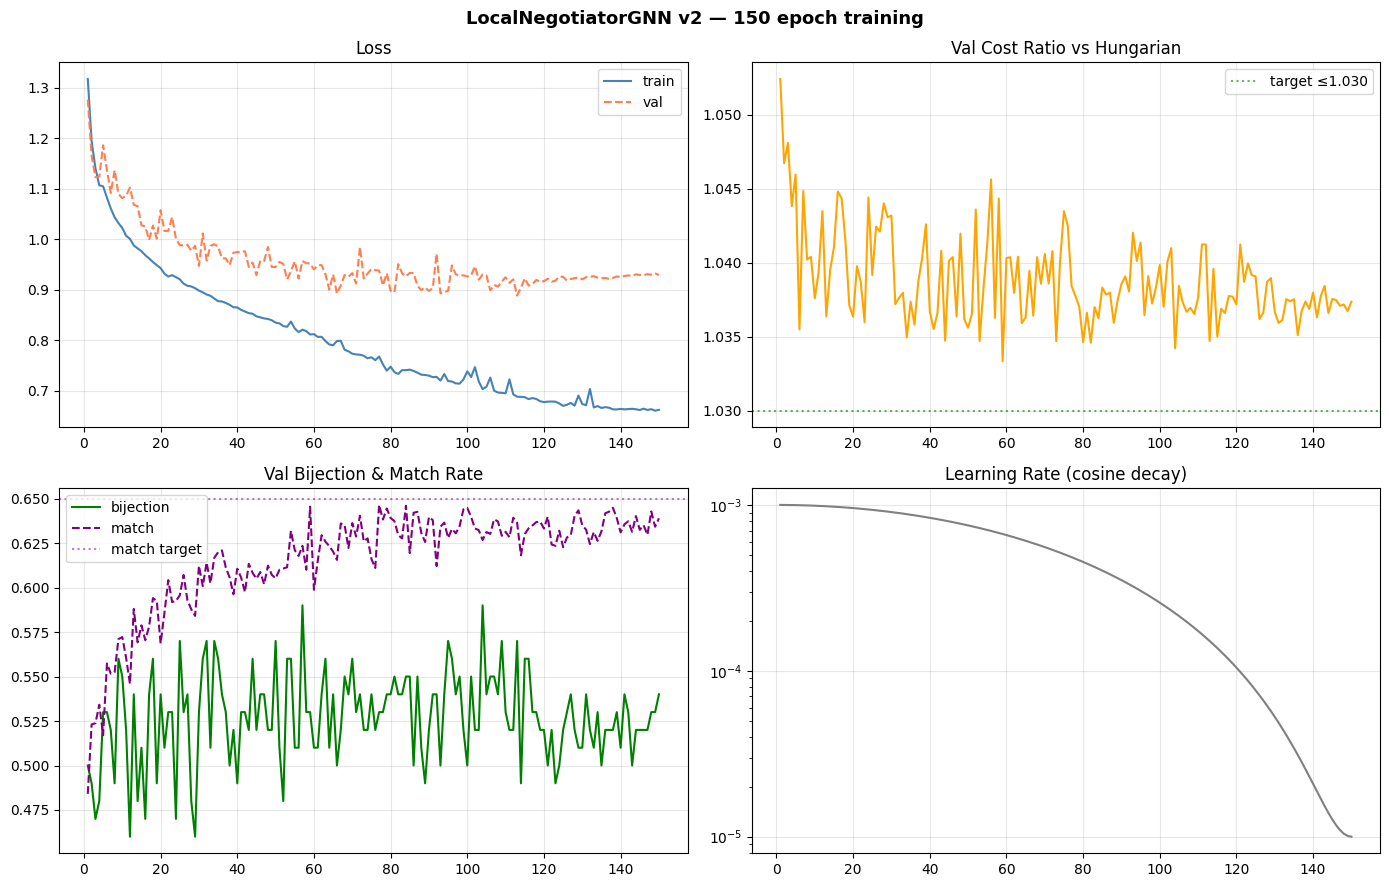

Saved base_encoder_training_curves.png


In [9]:
# ── Training curves ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('LocalNegotiatorGNN v2 — 150 epoch training', fontsize=13, fontweight='bold')
ep = range(1, len(history['train_loss']) + 1)

axes[0,0].plot(ep, history['train_loss'], label='train', color='steelblue')
axes[0,0].plot(ep, history['val_loss'],   label='val',   color='coral', linestyle='--')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, history['val_cost_ratio_vs_hungarian'], color='orange')
axes[0,1].axhline(1.03, color='green', linestyle=':', alpha=0.6, label='target ≤1.030')
axes[0,1].set_title('Val Cost Ratio vs Hungarian'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ep, history['val_bijection_rate'],  label='bijection', color='green')
axes[1,0].plot(ep, history['val_slot_match_rate'], label='match',     color='purple', linestyle='--')
axes[1,0].axhline(0.65, color='purple', linestyle=':', alpha=0.5, label='match target')
axes[1,0].set_title('Val Bijection & Match Rate'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, history['lr'], color='gray')
axes[1,1].set_title('Learning Rate (cosine decay)'); axes[1,1].grid(alpha=0.3)
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.savefig('base_encoder_training_curves.png', dpi=120)
plt.show()
print('Saved base_encoder_training_curves.png')

## Expected test set numbers — early-stopping guide

These are the numbers to expect on the **test set** (1,000 samples, strict visibility, gossip inference). Use them to detect problems early.

| Epoch | cost_ratio | slot_match | bijection | What to check if off |
|---|---|---|---|---|
| 50 | 1.055–1.070 | 0.55–0.60 | 0.42–0.48 | If cost_ratio > 1.10: dataset not loading, CUDA unavailable, or `force_gt_train` silently False |
| 100 | 1.035–1.050 | 0.62–0.67 | 0.47–0.53 | If stalled vs epoch 50: LR decay too fast — check cosine schedule is attached |
| 150 | 1.025–1.038 | 0.66–0.72 | 0.49–0.55 | If val–train loss gap > 0.15: overfitting — reduce to 6,000 train samples or add dropout |

**Bijection note:** Gossip consensus is structurally capped around 0.50–0.55 because of asymmetric information in the comm graph. A bijection rate of 0.50–0.55 at epoch 150 is correct — not a training failure. The Sinkhorn and Bertsekas downstream models will push bijection to 1.0 using the encoder's logits.

**Cost ratio note:** The cost ratio reflects gossip inference quality, not encoder quality directly. The encoder is better than the gossip number suggests — the Sinkhorn fine-tune starting from this checkpoint typically drops cost ratio by another 0.010–0.015 relative.

**If training is interrupted:** The mid-training checkpoint at `strict_local_negotiator_best.pt` always contains the best weights seen so far. You can resume evaluation from it without restarting training.